###  ANALISIS DEL:
 dataset_municipios_albacete_places_enriquecido_v3 

In [1]:
from pathlib import Path

# raíz del proyecto
ROOT = Path().resolve().parent

# carpetas de datos
DATA_RAW = ROOT / "data" / "raw"
DATA_INTERIM = ROOT / "data" / "interim"
DATA_PROCESSED = ROOT / "data" / "processed"

In [3]:
import pandas as pd

df = pd.read_csv(DATA_INTERIM / "dataset_municipios_albacete_places_enriquecido_v3.csv")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
df.head(3)

Filas: 87
Columnas: 10


,municipio,poblacion_2025,gyms_google,fitness_x10k,lat,lon,radius_m,gyms_google_new,gyms_sample_names,fitness_x10k_new
0,Abengibre,753,37,491.367862,39.210505,-1.541444,4000,0,NaN,0.000000
1,Alatoz,504,28,555.555556,39.095050,-1.361995,4000,0,NaN,0.000000
2,Albacete,175400,53,3.021665,38.994398,-1.860173,18000,78,"967GYM; ALMA SERENA ( CENTRO DE YOGA, MEDITACI...",4.446978


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   municipio          87 non-null     object 
 1   poblacion_2025     87 non-null     int64  
 2   gyms_google        87 non-null     int64  
 3   fitness_x10k       87 non-null     float64
 4   lat                87 non-null     float64
 5   lon                87 non-null     float64
 6   radius_m           87 non-null     int64  
 7   gyms_google_new    87 non-null     int64  
 8   gyms_sample_names  58 non-null     object 
 9   fitness_x10k_new   87 non-null     float64
dtypes: float64(4), int64(4), object(2)
memory usage: 6.9+ KB


In [3]:
# detectar posibles valores raros

df.sort_values("gyms_google_new", ascending=False)[
    ["municipio","poblacion_2025","gyms_google_new"]
].head(10)

,municipio,poblacion_2025,gyms_google_new
2,Albacete,175400,78
8,Almansa,24615,20
81,Villarrobledo,25400,20
36,Hellín,30836,16
69,"Roda, La",15643,16
73,Tarazona de la Mancha,6100,10
6,Alcalá del Júcar,1130,8
24,Caudete,10439,8
74,Tobarra,8006,5
26,Chinchilla de Monte-Aragón,4614,5


In [4]:
# detectar posibles valores raros

df.sort_values("fitness_x10k_new", ascending=False)[
    ["municipio","poblacion_2025","gyms_google_new","fitness_x10k_new"]
].head(10)

,municipio,poblacion_2025,gyms_google_new,fitness_x10k_new
82,Villatoya,114,1,87.719298
6,Alcalá del Júcar,1130,8,70.796460
30,Fuensanta,282,1,35.460993
39,Hoya-Gonzalo,582,2,34.364261
41,Letur,911,3,32.930845
37,"Herrera, La",308,1,32.467532
67,Riópar,1344,4,29.761905
19,Carcelén,483,1,20.703934
50,Montealegre del Castillo,2051,4,19.502682
22,Casas de Ves,519,1,19.267823


In [5]:
df["gyms_sample_names"].dropna().head(20)

2     967GYM; ALMA SERENA ( CENTRO DE YOGA, MEDITACI...
3                                     Circuito ALBATANA
4                    Polideportivo Municipal de Alborea
5                                  Gimnasio Sport Gim Z
6     Avenjúcar Multiaventura Alcalá del Júcar; Base...
7                         Circuito Club TT vado la Nava
8     AngelaSport; COYP Movimiento y Salud; Centro D...
9                             Gimnasio Municipal Alpera
10            Vía Ferrata Los Picarzos - Aýna - K2 y K4
11    Nutri-Gym Isabel; Pabellón Polideportivo Munic...
14     Gimnasio municipal; Pabellón Municipal de Barrax
15                    Gimnasio Municipal De Bienserbida
16                                      Caza del Molino
17           Pabellón Polideportivo Municipal de Bonete
18    Fuente de la Salud; Gym Loren; MUNERA Polidepo...
19                              Casa Rural "El Parador"
20        Pabellón Polideportivo de Casas de Juan Núñez
22                 Complejo Deportivo Valeriano 

In [9]:
import pandas as pd

out = pd.read_csv("dataset_municipios_albacete_places_enriquecido_v3.csv")

In [10]:
out.sort_values("gyms_google_new", ascending=False)[
    ["municipio","poblacion_2025","gyms_google_new"]
].head(10)

,municipio,poblacion_2025,gyms_google_new
2,Albacete,175400,78
8,Almansa,24615,20
81,Villarrobledo,25400,20
36,Hellín,30836,16
69,"Roda, La",15643,16
73,Tarazona de la Mancha,6100,10
6,Alcalá del Júcar,1130,8
24,Caudete,10439,8
74,Tobarra,8006,5
26,Chinchilla de Monte-Aragón,4614,5


In [14]:
# cargar el raw
import pandas as pd
import re

raw = pd.read_csv("places_all_results_v4.csv")

In [15]:
# crear nuevo filtro limpio
EXCLUDE_NAME = re.compile(r"""
multiaventura|aventura|
piragua|piraguas|
despedida|
rafting|kayak|
paintball
""", re.IGNORECASE | re.VERBOSE)

In [16]:
# aplicar filtro
raw_clean = raw[~raw["name"].str.contains(EXCLUDE_NAME, na=False)]

In [17]:
# quitar duplicados
raw_clean = raw_clean.drop_duplicates(subset="place_id")

In [18]:
# contar por municipios
gyms_clean = (
    raw_clean.groupby("municipio")
    .size()
    .reset_index(name="gyms_google_new")
)

In [19]:
# Unir con el dataset municipal
df = pd.read_csv("dataset_municipios_albacete_places_enriquecido_v3.csv")

df = df.drop(columns=["gyms_google_new","fitness_x10k_new"])

df = df.merge(gyms_clean, on="municipio", how="left")

df["gyms_google_new"] = df["gyms_google_new"].fillna(0)

In [20]:
# recalcular ratio
df["fitness_x10k_new"] = (df["gyms_google_new"] / df["poblacion_2025"]) * 10000

In [21]:
# guardar dataset limpio
df.to_csv("dataset_municipios_albacete_places_enriquecido_v4.csv", index=False)

In [22]:
# Comprobar Alcala del jucar
df[df["municipio"]=="Alcalá del Júcar"]

,municipio,poblacion_2025,gyms_google,fitness_x10k,lat,lon,radius_m,gyms_sample_names,gyms_google_new,fitness_x10k_new
6,Alcalá del Júcar,1130,22,194.690265,39.191778,-1.429571,6000,Avenjúcar Multiaventura Alcalá del Júcar; Base...,1.0,8.849558


In [24]:
df.columns

Index(['municipio', 'poblacion_2025', 'gyms_google', 'fitness_x10k', 'lat',
       'lon', 'radius_m', 'gyms_sample_names', 'gyms_google_new',
       'fitness_x10k_new'],
      dtype='object')

In [25]:
# Funcion de distancia
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    
    R = 6371
    
    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    return R * c

In [26]:
# Calcular poblacion den 25km
catchment_pop = []

for i, row in df.iterrows():
    
    total_pop = 0
    
    for j, row2 in df.iterrows():
        
        dist = haversine_km(
            row["lat"], row["lon"],
            row2["lat"], row2["lon"]
        )
        
        if dist <= 25:
            total_pop += row2["poblacion_2025"]
    
    catchment_pop.append(total_pop)

df["catchment_pop_25km"] = catchment_pop

In [27]:
# Mercado real
df["real_market_potential"] = (
    df["catchment_pop_25km"] /
    (df["gyms_google_new"] + 1)
)

In [28]:
# ver oportunidades
df.sort_values("real_market_potential", ascending=False)[
    ["municipio","poblacion_2025","catchment_pop_25km","gyms_google_new","real_market_potential"]
].head(15)

,municipio,poblacion_2025,catchment_pop_25km,gyms_google_new,real_market_potential
49,Montalvos,74,208803,0.0,208803.000000
51,Motilleja,673,199093,0.0,199093.000000
37,"Herrera, La",308,201464,1.0,100732.000000
61,Pozo Cañada,2704,195301,1.0,97650.500000
34,"Gineta, La",2656,208803,2.0,69601.000000
75,Valdeganga,1970,208108,2.0,69369.333333
35,Golosalvo,79,32267,0.0,32267.000000
26,Chinchilla de Monte-Aragón,4614,188775,5.0,31462.500000
45,Mahora,1465,30465,0.0,30465.000000
53,Navas de Jorquera,521,29662,0.0,29662.000000


In [29]:
# penalizar cercania a cidades grandes
# coordenadas de Albacete capital (de tu propio df)

ab = df[df["municipio"]=="Albacete"].iloc[0]
lat_ab, lon_ab = ab["lat"], ab["lon"]

dist_cap = []
for _, r in df.iterrows():
    d = haversine_km(r["lat"], r["lon"], lat_ab, lon_ab)
    dist_cap.append(d)

df["dist_albacete_km"] = dist_cap

In [ ]:
# score final con penalizacion
import numpy as np

# penalización suave: si está a 0–15 km de Albacete baja mucho
penalty = np.clip(df["dist_albacete_km"] / 25, 0.3, 1.0)

df["opportunity_score"] = (
    df["catchment_pop_25km"] /
    (df["gyms_google_new"] + 1)
) * penalty

In [ ]:
# Ranking final
df.sort_values("opportunity_score", ascending=False)[
    ["municipio","dist_albacete_km","catchment_pop_25km",
     "gyms_google_new","opportunity_score"]
].head(15)

,municipio,dist_albacete_km,catchment_pop_25km,gyms_google_new,opportunity_score
49,Montalvos,23.913369,208803,0.0,199727.329177
51,Motilleja,21.517139,199093,0.0,171356.469913
37,"Herrera, La",23.284198,201464,1.0,93818.552893
61,Pozo Cañada,23.992871,195301,1.0,93716.633374
75,Valdeganga,22.286421,208108,2.0,61839.765632
34,"Gineta, La",17.677932,208803,2.0,49216.068746
35,Golosalvo,33.426709,32267,0.0,32267.000000
45,Mahora,26.939859,30465,0.0,30465.000000
53,Navas de Jorquera,34.013851,29662,0.0,29662.000000
40,Jorquera,35.468967,29553,0.0,29553.000000


In [32]:
# calcular competencia en 25km
catchment_gyms = []

for i, row in df.iterrows():
    total_gyms = 0
    
    for j, row2 in df.iterrows():
        dist = haversine_km(row["lat"], row["lon"], row2["lat"], row2["lon"])
        
        if dist <= 25:
            total_gyms += row2["gyms_google_new"]
    
    catchment_gyms.append(total_gyms)

df["catchment_gyms_25km"] = catchment_gyms

In [33]:
# score correcto
df["opportunity_score_v2"] = df["catchment_pop_25km"] / (df["catchment_gyms_25km"] + 1)

In [34]:
# ranking nuevo
df.sort_values("opportunity_score_v2", ascending=False)[
    ["municipio","dist_albacete_km",
     "catchment_pop_25km","catchment_gyms_25km",
     "opportunity_score_v2"]
].head(15)

,municipio,dist_albacete_km,catchment_pop_25km,catchment_gyms_25km,opportunity_score_v2
2,Albacete,0.000000,188399,89.0,2093.322222
61,Pozo Cañada,23.992871,195301,95.0,2034.385417
26,Chinchilla de Monte-Aragón,14.328993,188775,92.0,2029.838710
37,"Herrera, La",23.284198,201464,102.0,1955.961165
51,Motilleja,21.517139,199093,102.0,1932.941748
75,Valdeganga,22.286421,208108,110.0,1874.846847
34,"Gineta, La",17.677932,208803,115.0,1800.025862
49,Montalvos,23.913369,208803,115.0,1800.025862
3,Albatana,55.430927,43803,24.0,1752.120000
74,Tobarra,47.139998,46681,26.0,1728.925926


In [35]:
df_rank = df[df["poblacion_2025"] >= 1000].copy()

In [36]:
# Guardar dataset
df.to_csv("gym_market_opportunity_albacete.csv", index=False)

### entrenando 

In [ ]:
# Voy a dividir los municipios en 4 grupos
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

features = [
    "poblacion_2025",
    "gyms_google_new",
    "fitness_x10k_new",
    "catchment_pop_25km",
    "catchment_gyms_25km",
    "dist_albacete_km"
]

X = df[features].copy()

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42, n_init="auto"))
])

df["cluster"] = pipe.fit_predict(X)

df[["municipio","cluster"] + features].sort_values(["cluster","catchment_pop_25km"], ascending=[True, False]).head(20)

,municipio,cluster,poblacion_2025,gyms_google_new,fitness_x10k_new,catchment_pop_25km,catchment_gyms_25km,dist_albacete_km
43,Liétor,0,1052,2.0,19.011407,51626,34.0,50.986118
55,Ontur,0,1895,1.0,5.277045,46817,29.0,52.505955
74,Tobarra,0,8006,5.0,6.245316,46681,26.0,47.139998
47,Minaya,0,1381,1.0,7.241130,43865,39.0,50.254145
3,Albatana,0,644,1.0,15.527950,43803,24.0,55.430927
50,Montealegre del Castillo,0,2051,4.0,19.502682,36307,32.0,51.491544
17,Bonete,0,950,1.0,10.526316,35498,33.0,46.346868
9,Alpera,0,2278,1.0,4.389816,32317,29.0,54.601895
35,Golosalvo,0,79,0.0,0.000000,32267,30.0,33.426709
30,Fuensanta,0,282,1.0,35.460993,31965,35.0,33.197454


In [ ]:
# Vamos a probar modelos con 2,3,4,5,6,7,8 y 9 clusters
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ks = range(2,10)

inertia = []
silhouette = []

for k in ks:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

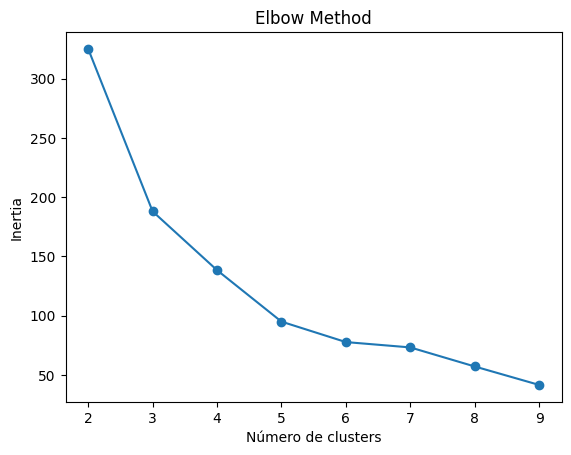

In [39]:
plt.figure()
plt.plot(ks, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

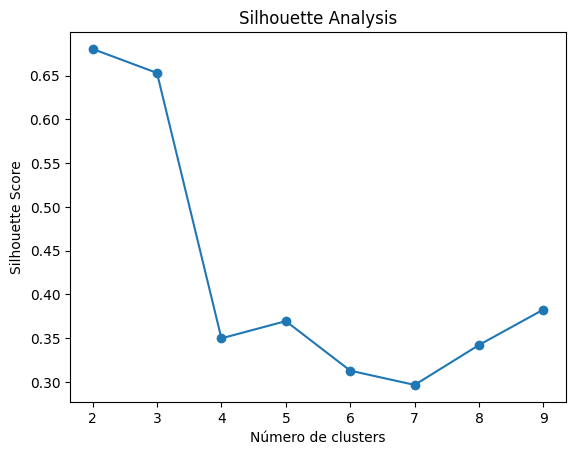

In [40]:
plt.figure()
plt.plot(ks, silhouette, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Qué aprenderemos con los clusters
Una vez elegimos k, el modelo agrupará municipios con características similares.
Podrían salir grupos como:
Cluster A
- pueblos pequeños
- poca competencia
- mercados locales

Cluster B
- ciudades medianas
- competencia moderada

Cluster C
- satélites de Albacete

Cluster D
- capital provincial

In [41]:
# población accesible alrededor de cada municipio.
FITNESS_PENETRATION = 0.12

df["fitness_market_capacity"] = (
    df["catchment_pop_25km"] * FITNESS_PENETRATION
)

In [42]:
# estimar competencia por cliente
df["clients_per_gym"] = (
    df["fitness_market_capacity"] /
    (df["catchment_gyms_25km"] + 1)
)

In [ ]:
# visualizamos 
df.sort_values("clients_per_gym", ascending=False)[
[
"municipio",
"catchment_pop_25km",
"catchment_gyms_25km",
"fitness_market_capacity",
"clients_per_gym"
]
].head(15)

,municipio,catchment_pop_25km,catchment_gyms_25km,fitness_market_capacity,clients_per_gym
2,Albacete,188399,89.0,22607.88,251.198667
61,Pozo Cañada,195301,95.0,23436.12,244.126250
26,Chinchilla de Monte-Aragón,188775,92.0,22653.00,243.580645
37,"Herrera, La",201464,102.0,24175.68,234.715340
51,Motilleja,199093,102.0,23891.16,231.953010
75,Valdeganga,208108,110.0,24972.96,224.981622
34,"Gineta, La",208803,115.0,25056.36,216.003103
49,Montalvos,208803,115.0,25056.36,216.003103
3,Albatana,43803,24.0,5256.36,210.254400
74,Tobarra,46681,26.0,5601.72,207.471111


###############################################################
# SECCIÓN — INTEGRAR RENTA MEDIA
###############################################################

In [ ]:
# Descargar datos de IRPF por municipios y comunidades autónomas
import requests

url = "https://sede.agenciatributaria.gob.es/AEAT/Contenidos_Comunes/La_Agencia_Tributaria/Estadisticas/Publicaciones/sites/irpfmunicipios_ccaa/2023/docs/irpf_municipios_ccaa/2023/irpf_municipios_ccaa-2023_Castilla-LaMancha.xlsx"
out_path = "irpf_municipios_2023_CastillaLaMancha.xlsx"

r = requests.get(url, timeout=60)
r.raise_for_status()

with open(out_path, "wb") as f:
    f.write(r.content)

print("OK, guardado:", out_path, "bytes:", len(r.content))

OK, guardado: irpf_municipios_2023_CastillaLaMancha.xlsx bytes: 3053709


In [50]:
# Cargar datos de IRPF
import pandas as pd

renta_raw = pd.read_excel("irpf_municipios_2023_CastillaLaMancha.xlsx")
print(renta_raw.shape)
renta_raw.head()

(5, 1)


c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0
0,Municipio/s de Castilla-La Mancha 2023
1,Metadatos
2,Declaraciones por Municipios del IRPF 2023
3,Importes de las partidas por Municipios ...
4,Clasificación por Municipios y Tramos de...


In [52]:
# vemos las hojas
import pandas as pd

xls = pd.ExcelFile("irpf_municipios_2023_CastillaLaMancha.xlsx")

xls.sheet_names

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


['Index', 'Metadatos', 'Variables Clasificación', '1.1', '1.2', '1.3']

In [58]:
import pandas as pd

file = "irpf_municipios_2023_CastillaLaMancha.xlsx"
sheet = "1.3"

raw = pd.read_excel(file, sheet_name=sheet, header=None, nrows=120)

# encontrar fila donde aparece "Municip" o "MUNICIPIO"
header_row = None
for i in range(len(raw)):
    row_text = " ".join(raw.iloc[i].astype(str).fillna("").tolist()).upper()
    if "MUNICIP" in row_text:
        header_row = i
        break

print("Header row detectada:", header_row)

data = pd.read_excel(file, sheet_name=sheet, header=header_row)

# limpiar columnas vacías
data = data.dropna(axis=1, how="all")

data.head(10)

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Header row detectada: 2


,Clasificación por Municipios y Tramos de Base,Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,Indice,Metadatos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Provincias,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Castilla-La Mancha,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tramo de Base Imponible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"Hasta de 6.010,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"6.010,01 - 12.020,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,"12.020,01 - 18.030,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"18.030,01 - 21.035,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,"De 21.035,00 a 30.050,61",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# Encontrar la fila donde está el header REAL
import pandas as pd

file = "irpf_municipios_2023_CastillaLaMancha.xlsx"
sheet = "1.3"

raw = pd.read_excel(file, sheet_name=sheet, header=None, nrows=350)

hits = []
for i in range(len(raw)):
    row_text = " | ".join(raw.iloc[i].astype(str).fillna("").tolist()).upper()
    if "MUNICIP" in row_text or "PROVINC" in row_text:
        hits.append((i, row_text[:200]))

hits[:20], len(hits)

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


([(2,
   'CLASIFICACIÓN POR MUNICIPIOS Y TRAMOS DE BASE | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NA'),
  (4,
   '\xa0\xa0\xa0\xa0\xa0\xa0 PROVINCIAS  | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN | NAN |'),
  (175,
   'NAN | NAN | NAN | NAN | DISTRIBUCIÓN GEOGRÁFICA | NAN | NAN | CÓDIGO\nMUNICIPIO | IMPORTE\nPARTIDA  435 | DECLARANTES\n435 | IMPORTE\nPARTIDA  460 | DECLARANTES\n460 | IMPORTE\nPARTIDA  505 | DECLARANTES\n50'),
  (270,
   'NAN | NAN | NAN | NAN | DISTRIBUCIÓN GEOGRÁFICA | NAN | NAN | CÓDIGO\nMUNICIPIO | IMPORTE\nPARTIDA  435 | DECLARANTES\n435 | IMPORTE\nPARTIDA  460 | DECLARANTES\n460 | IMPORTE\nPARTIDA  505 | DECLARANTES\n50')],
 4)

In [62]:
# Leer la tabla desde la fila 175
import pandas as pd

file = "irpf_municipios_2023_CastillaLaMancha.xlsx"
sheet = "1.3"
HEADER_ROW = 175

data = pd.read_excel(file, sheet_name=sheet, header=HEADER_ROW)
data = data.dropna(axis=1, how="all")
data = data.dropna(axis=0, how="all")

data.head(10)

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 3,Distribución Geográfica,Unnamed: 5,Unnamed: 6,Código\nMunicipio,Importe\nPartida 435,Declarantes\n435,Importe\nPartida 460,Declarantes\n460,Importe\nPartida 505,...,Declarantes\n545,Importe\nPartida 570,Declarantes\n570,Importe\nPartida 595,Declarantes\n595,Suma deducciones (parte\nestatal),Suma deducciones (parte\nautonómica,Declarantes deducciones\n(parte estatal),Declarantes deducciones\n(parte autonómica),Número total\ndeclaraciones
0,NaN,Castilla-La Mancha,Albacete,NaN,NaN,3808303887.2,191391,217988053.71,82130,3681776201.15,...,129348,357322097.94,127223,705415163.98,127368,10965738.42,19874915.86,48149,69055,204739
1,NaN,NaN,Albacete,Abengibre-02001,02001,4654644.73,347,182886.84,229,4442814.87,...,190,327829.08,187,593167.55,187,5517.11,71305.92,39,179,368
2,NaN,NaN,NaN,Alatoz-02002,02002,3178618.46,240,83031.95,111,2981125.79,...,127,192698.53,127,349620.09,127,3639.23,40570.21,32,115,257
3,NaN,NaN,NaN,Albacete-02003,02003,2216620982.75,92467,134673335.68,39179,2160869362.42,...,69295,227169370.59,68293,452575297.99,68355,6822315.25,8276983.73,28338,33717,98166
4,NaN,NaN,NaN,Albatana-02004,02004,4020828.29,309,106977.05,213,3774218.07,...,160,266430.11,159,493123.89,159,4505.97,44777,41,126,328
5,NaN,NaN,NaN,Alborea-02005,02005,3807699.74,311,503725.37,184,3607850.34,...,153,296005.12,150,539817.49,150,3094.73,56662.37,27,126,331
6,NaN,NaN,NaN,Alcadozo-02006,02006,3317401.7,240,76185.79,65,3110630.51,...,112,239212.24,112,429244.31,112,3978.59,53407.98,22,98,250
7,NaN,NaN,NaN,Alcalá del Júcar-02007,02007,7128997.63,509,361740.47,272,6820248.34,...,277,603593.95,277,1098884.34,277,5985.09,116787.47,58,246,539
8,NaN,NaN,NaN,Alcaraz-02008,02008,9606119.55,608,515990.18,240,9197448.08,...,365,786044.75,360,1407176.73,360,20236.96,187944.33,114,332,641
9,NaN,NaN,NaN,Almansa-02009,02009,208632242.88,11074,13468870.33,4723,201033692,...,7716,19015953.33,7552,37918488.44,7560,628133.13,717029.25,2913,3483,11958


In [70]:
import pandas as pd

ruta = "irpf_municipios_2023_CastillaLaMancha.xlsx"

df_renta = pd.read_excel(
    ruta,
    sheet_name="1.3",
    header=175
)

df_renta.head()

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Distribución Geográfica,Unnamed: 5,Unnamed: 6,Código\nMunicipio,Importe\nPartida 435,Declarantes\n435,...,Declarantes\n545,Importe\nPartida 570,Declarantes\n570,Importe\nPartida 595,Declarantes\n595,Suma deducciones (parte\nestatal),Suma deducciones (parte\nautonómica,Declarantes deducciones\n(parte estatal),Declarantes deducciones\n(parte autonómica),Número total\ndeclaraciones
0,NaN,NaN,NaN,NaN,Castilla-La Mancha,Albacete,NaN,NaN,3808303887.2,191391,...,129348,357322097.94,127223,705415163.98,127368,10965738.42,19874915.86,48149,69055,204739
1,NaN,NaN,NaN,NaN,NaN,Albacete,Abengibre-02001,02001,4654644.73,347,...,190,327829.08,187,593167.55,187,5517.11,71305.92,39,179,368
2,NaN,NaN,NaN,NaN,NaN,NaN,Alatoz-02002,02002,3178618.46,240,...,127,192698.53,127,349620.09,127,3639.23,40570.21,32,115,257
3,NaN,NaN,NaN,NaN,NaN,NaN,Albacete-02003,02003,2216620982.75,92467,...,69295,227169370.59,68293,452575297.99,68355,6822315.25,8276983.73,28338,33717,98166
4,NaN,NaN,NaN,NaN,NaN,NaN,Albatana-02004,02004,4020828.29,309,...,160,266430.11,159,493123.89,159,4505.97,44777,41,126,328


In [71]:
# limpiar nombres de columnas
df_renta.columns = df_renta.columns.str.replace("\n", " ")

df_renta.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3',
       'Distribución Geográfica', 'Unnamed: 5', 'Unnamed: 6',
       'Código Municipio', 'Importe Partida  435', 'Declarantes 435',
       'Importe Partida  460', 'Declarantes 460', 'Importe Partida  505',
       'Declarantes 505', 'Importe Partida  25', 'Declarantes 25',
       'Importe Partida  235', 'Declarantes 235', 'Importe Partida  1484',
       'Declarantes 1484', 'Importe Partida  1560', 'Declarantes 1560',
       'Importe Partida  545', 'Declarantes 545', 'Importe Partida  570',
       'Declarantes 570', 'Importe Partida  595', 'Declarantes 595',
       'Suma deducciones (parte estatal)',
       'Suma deducciones (parte autonómica',
       'Declarantes deducciones (parte estatal)',
       'Declarantes deducciones (parte autonómica)',
       'Número total declaraciones'],
      dtype='object')

In [72]:
# Seleccionar columnas importantes
df_renta = df_renta[[
    "Distribución Geográfica",
    "Código Municipio",
    "Importe Partida  435",
    "Declarantes 435"
]]

df_renta.head()

,Distribución Geográfica,Código Municipio,Importe Partida 435,Declarantes 435
0,Castilla-La Mancha,NaN,3808303887.2,191391
1,NaN,02001,4654644.73,347
2,NaN,02002,3178618.46,240
3,NaN,02003,2216620982.75,92467
4,NaN,02004,4020828.29,309


In [73]:
# Traer la columna con “Municipio-Código” y separar nombre
# Volvemos a leer solo para traer la columna donde viene "Alatoz-02002"
df_tmp = pd.read_excel(
    "irpf_municipios_2023_CastillaLaMancha.xlsx",
    sheet_name="1.3",
    header=175,
    usecols=["Unnamed: 6", "Código\nMunicipio", "Importe\nPartida  435", "Declarantes\n435"]
)

# limpiar saltos de línea en nombres
df_tmp.columns = df_tmp.columns.str.replace("\n", " ")

# renombrar
df_tmp = df_tmp.rename(columns={
    "Unnamed: 6": "muni_codigo",
    "Código Municipio": "codigo_municipio",
    "Importe Partida  435": "importe_irpf",
    "Declarantes 435": "declarantes"
})

# extraer nombre de municipio (parte antes del guion)
df_tmp["municipio"] = df_tmp["muni_codigo"].astype(str).str.split("-").str[0]

df_tmp.head(8)

c:\Users\juanc\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,muni_codigo,codigo_municipio,importe_irpf,declarantes,municipio
0,NaN,NaN,3808303887.2,191391,nan
1,Abengibre-02001,02001,4654644.73,347,Abengibre
2,Alatoz-02002,02002,3178618.46,240,Alatoz
3,Albacete-02003,02003,2216620982.75,92467,Albacete
4,Albatana-02004,02004,4020828.29,309,Albatana
5,Alborea-02005,02005,3807699.74,311,Alborea
6,Alcadozo-02006,02006,3317401.7,240,Alcadozo
7,Alcalá del Júcar-02007,02007,7128997.63,509,Alcalá del Júcar


In [ ]:
# quitar totales y filtrar provincia
df_renta_ab = df_tmp[
    df_tmp["codigo_municipio"].notna() &
    df_tmp["codigo_municipio"].astype(str).str.startswith("02")
].copy()

df_renta_ab.head()

,muni_codigo,codigo_municipio,importe_irpf,declarantes,municipio
1,Abengibre-02001,02001,4654644.73,347,Abengibre
2,Alatoz-02002,02002,3178618.46,240,Alatoz
3,Albacete-02003,02003,2216620982.75,92467,Albacete
4,Albatana-02004,02004,4020828.29,309,Albatana
5,Alborea-02005,02005,3807699.74,311,Alborea


In [76]:
# Crear la renta media proxy (Importe / Declarantes)
# Convertir a número (si hay cosas raras, las convierte en NaN)
df_renta_ab["importe_irpf"] = pd.to_numeric(df_renta_ab["importe_irpf"], errors="coerce")
df_renta_ab["declarantes"] = pd.to_numeric(df_renta_ab["declarantes"], errors="coerce")

# Crear renta media proxy
df_renta_ab["renta_media_proxy"] = df_renta_ab["importe_irpf"] / df_renta_ab["declarantes"]

df_renta_ab[["municipio", "codigo_municipio", "importe_irpf", "declarantes", "renta_media_proxy"]].head()

,municipio,codigo_municipio,importe_irpf,declarantes,renta_media_proxy
1,Abengibre,02001,4.654645e+06,347.0,13413.961758
2,Alatoz,02002,3.178618e+06,240.0,13244.243583
3,Albacete,02003,2.216621e+09,92467.0,23972.022265
4,Albatana,02004,4.020828e+06,309.0,13012.389288
5,Alborea,02005,3.807700e+06,311.0,12243.407524


In [77]:
# cargamos dataset de municipios
df_main = pd.read_csv("dataset_municipios_albacete_places_enriquecido_v4.csv")

df_main.columns

Index(['municipio', 'poblacion_2025', 'gyms_google', 'fitness_x10k', 'lat',
       'lon', 'radius_m', 'gyms_sample_names', 'gyms_google_new',
       'fitness_x10k_new'],
      dtype='object')

In [78]:
# Normalizar nombres de municipio en ambos datasets
df_main["municipio"] = df_main["municipio"].str.strip().str.upper()
df_renta_ab["municipio"] = df_renta_ab["municipio"].str.strip().str.upper()

df_main["municipio"].head()

0    ABENGIBRE
1       ALATOZ
2     ALBACETE
3     ALBATANA
4      ALBOREA
Name: municipio, dtype: object

### Merge de los datasets

In [79]:
df_main = df_main.merge(
    df_renta_ab[["municipio", "renta_media_proxy"]],
    on="municipio",
    how="left"
)

df_main.head()

,municipio,poblacion_2025,gyms_google,fitness_x10k,lat,lon,radius_m,gyms_sample_names,gyms_google_new,fitness_x10k_new,renta_media_proxy
0,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.0,13413.961758
1,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.0,2501.660459
2,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.0,8627.220920
3,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.0,14748.332549
4,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.0,NaN


In [80]:
# ahora dejamos una sola renta por municipio
df_renta_clean = df_renta_ab.groupby("municipio", as_index=False)["renta_media_proxy"].mean()

df_renta_clean.head()

,municipio,renta_media_proxy
0,ABENGIBRE,16879.362259
1,ALATOZ,17200.977988
2,ALBACETE,27033.262372
3,ALBATANA,16662.723520
4,ALBOREA,15489.355616


In [81]:
# ahora si hacemos el merge limpio
df_main = pd.read_csv("dataset_municipios_albacete_places_enriquecido_v4.csv")
df_main["municipio"] = df_main["municipio"].str.strip().str.upper()

df_main = df_main.merge(
    df_renta_clean,
    on="municipio",
    how="left"
)

df_main.head()

,municipio,poblacion_2025,gyms_google,fitness_x10k,lat,lon,radius_m,gyms_sample_names,gyms_google_new,fitness_x10k_new,renta_media_proxy
0,ABENGIBRE,753,37,491.367862,39.210505,-1.541444,4000,NaN,0.0,0.000000,16879.362259
1,ALATOZ,504,28,555.555556,39.095050,-1.361995,4000,NaN,0.0,0.000000,17200.977988
2,ALBACETE,175400,53,3.021665,38.994398,-1.860173,18000,"967GYM; ALMA SERENA ( CENTRO DE YOGA, MEDITACI...",78.0,4.446978,27033.262372
3,ALBATANA,644,46,714.285714,38.572000,-1.520560,4000,Circuito ALBATANA,1.0,15.527950,16662.723520
4,ALBOREA,672,20,297.619048,39.279205,-1.395773,4000,Polideportivo Municipal de Alborea,1.0,14.880952,15489.355616


In [82]:
# chequear nulos
# 1) cuántos municipios sin renta
nan_renta = df_main["renta_media_proxy"].isna().sum()

# 2) cuántos municipios repetidos (debería ser 0 si municipio es único)
dup_munis = df_main["municipio"].duplicated().sum()

nan_renta, dup_munis

(np.int64(6), np.int64(0))

In [83]:
# guardamos dataser
df_main.to_csv(
    "dataset_municipios_albacete_places_enriquecido_v5.csv",
    index=False
)

### Ahora ya esta limpiio, vamos a analisar y extraer informacion


In [84]:
# vemos estadistica basica de la renta
df_main["renta_media_proxy"].describe()

count       81.000000
mean     20233.334523
std       5428.739313
min       6763.235535
25%      16665.710124
50%      17591.334478
75%      24851.405641
max      30931.330100
Name: renta_media_proxy, dtype: float64

In [85]:
# Ver los municipios más ricos
df_main.sort_values(
    "renta_media_proxy",
    ascending=False
)[["municipio", "poblacion_2025", "renta_media_proxy", "gyms_google_new"]].head(10)

,municipio,poblacion_2025,renta_media_proxy,gyms_google_new
14,BARRAX,1838,30931.330100,2.0
32,FUENTEALBILLA,1804,28509.867176,3.0
11,BALAZOTE,2356,27845.196466,2.0
6,ALCALÁ DEL JÚCAR,1130,27589.204464,1.0
71,SAN PEDRO,1155,27455.590023,1.0
58,PEÑAS DE SAN PEDRO,1488,27403.907388,2.0
44,MADRIGUERAS,4670,27046.547735,4.0
2,ALBACETE,175400,27033.262372,78.0
63,POZOHONDO,1544,26826.063443,1.0
29,ELCHE DE LA SIERRA,3603,26603.295752,2.0


In [86]:
# Crear un indicador simple de presión de mercado
df_main["gyms_per_10k"] = (
    df_main["gyms_google_new"] / df_main["poblacion_2025"]
) * 10000

df_main[["municipio", "poblacion_2025", "gyms_google_new", "gyms_per_10k"]].head()

,municipio,poblacion_2025,gyms_google_new,gyms_per_10k
0,ABENGIBRE,753,0.0,0.000000
1,ALATOZ,504,0.0,0.000000
2,ALBACETE,175400,78.0,4.446978
3,ALBATANA,644,1.0,15.527950
4,ALBOREA,672,1.0,14.880952


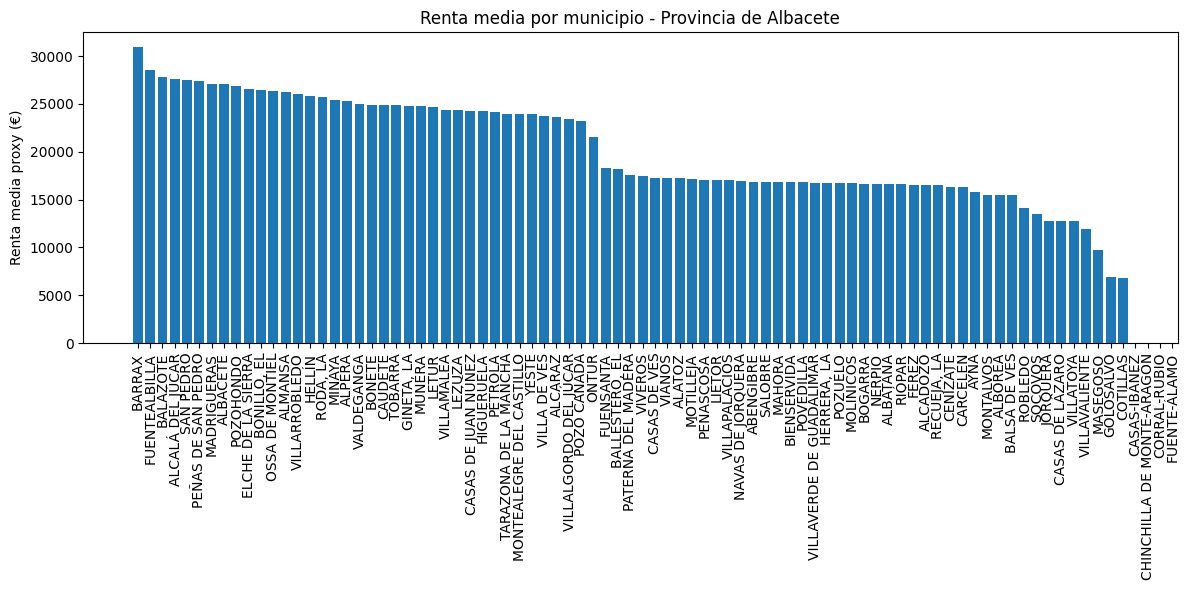

In [87]:
# Gráfico de renta por municipio
import matplotlib.pyplot as plt

df_plot = df_main.sort_values("renta_media_proxy", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_plot["municipio"], df_plot["renta_media_proxy"])

plt.xticks(rotation=90)
plt.ylabel("Renta media proxy (€)")
plt.title("Renta media por municipio - Provincia de Albacete")

plt.tight_layout()
plt.show()

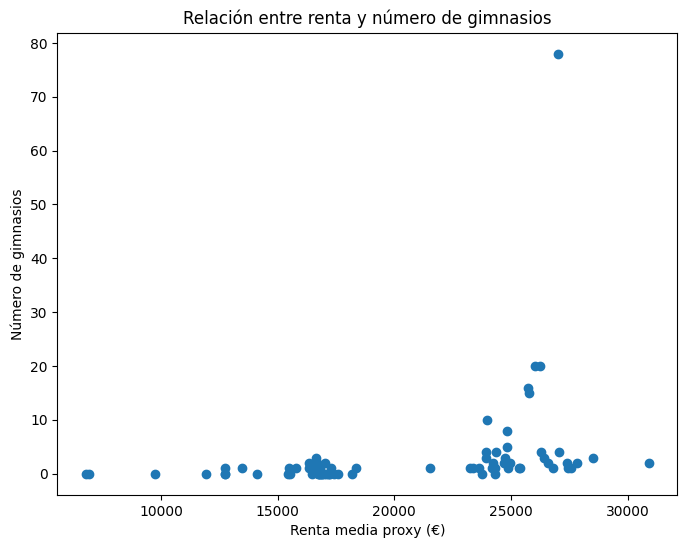

In [88]:
# Scatter plot: renta vs gimnasios
plt.figure(figsize=(8,6))

plt.scatter(
    df_main["renta_media_proxy"],
    df_main["gyms_google_new"]
)

plt.xlabel("Renta media proxy (€)")
plt.ylabel("Número de gimnasios")
plt.title("Relación entre renta y número de gimnasios")

plt.show()

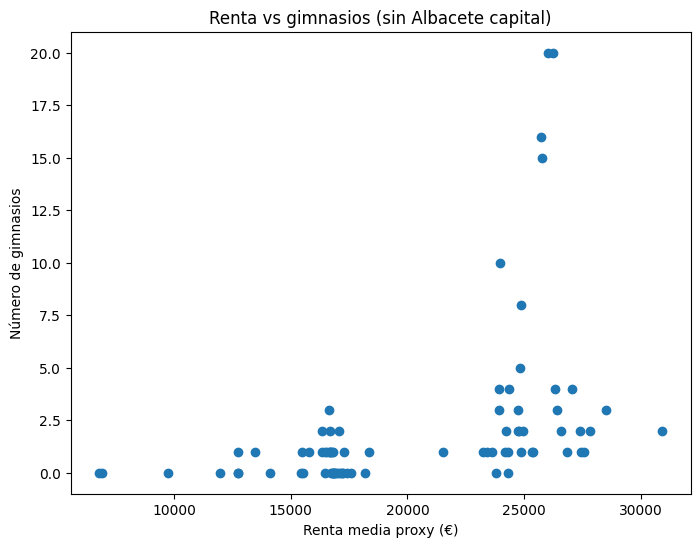

In [89]:
df_no_capital = df_main[df_main["municipio"] != "ALBACETE"]

plt.figure(figsize=(8,6))

plt.scatter(
    df_no_capital["renta_media_proxy"],
    df_no_capital["gyms_google_new"]
)

plt.xlabel("Renta media proxy (€)")
plt.ylabel("Número de gimnasios")
plt.title("Renta vs gimnasios (sin Albacete capital)")

plt.show()

In [91]:
# Crear un indicador simple de oportunidad de mercado
df_main["market_opportunity"] = (
    df_main["poblacion_2025"] * df_main["renta_media_proxy"]
) / (df_main["gyms_google_new"] + 1)

In [92]:
# Ranking por oportunidad de mercado
df_main["market_opportunity"] = (
    df_main["poblacion_2025"] * df_main["renta_media_proxy"]
) / (df_main["gyms_google_new"] + 1)

In [93]:
# ahora vemos el ranking
df_main.sort_values(
    "market_opportunity",
    ascending=False
)[["municipio","poblacion_2025","renta_media_proxy","gyms_google_new","market_opportunity"]].head(10)

,municipio,poblacion_2025,renta_media_proxy,gyms_google_new,market_opportunity
2,ALBACETE,175400,27033.262372,78.0,6.002069e+07
36,HELLÍN,30836,25778.606917,15.0,4.968182e+07
74,TOBARRA,8006,24840.208807,5.0,3.314512e+07
29,ELCHE DE LA SIERRA,3603,26603.295752,2.0,3.195056e+07
81,VILLARROBLEDO,25400,26034.238847,20.0,3.148903e+07
61,POZO CAÑADA,2704,23258.972196,1.0,3.144613e+07
42,LEZUZA,1281,24316.014189,0.0,3.114881e+07
8,ALMANSA,24615,26263.338685,20.0,3.078438e+07
9,ALPERA,2278,25335.332222,1.0,2.885694e+07
24,CAUDETE,10439,24851.405641,8.0,2.882487e+07


In [ ]:
# Normalizar variables (Min–Max)
from sklearn.preprocessing import MinMaxScaler

features = ["poblacion_2025", "renta_media_proxy", "gyms_google_new"]

scaler = MinMaxScaler()

df_scaled = df_main.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

df_scaled[features].head()

,poblacion_2025,renta_media_proxy,gyms_google_new
0,0.004003,0.418574,0.000000
1,0.002583,0.431881,0.000000
2,1.000000,0.838710,1.000000
3,0.003382,0.409610,0.012821
4,0.003542,0.361059,0.012821


In [95]:
# Crear un Opportunity Score balanceado / más población + más renta + menos gimnasios.
df_scaled["opportunity_score"] = (
    0.4 * df_scaled["poblacion_2025"] +
    0.4 * df_scaled["renta_media_proxy"] +
    0.2 * (1 - df_scaled["gyms_google_new"])
) * 100

In [ ]:
# ver los mejores mercados
df_scaled.sort_values(
    "opportunity_score",
    ascending=False
)[["municipio","poblacion_2025","renta_media_proxy","gyms_google_new","opportunity_score"]].head(10)

,municipio,poblacion_2025,renta_media_proxy,gyms_google_new,opportunity_score
2,ALBACETE,1.000000,0.838710,1.000000,73.548407
14,BARRAX,0.010191,1.000000,0.025641,59.894824
32,FUENTEALBILLA,0.009997,0.899807,0.038462,55.622956
11,BALAZOTE,0.013145,0.872305,0.025641,54.905207
36,HELLÍN,0.175564,0.786796,0.192308,54.648271
6,ALCALÁ DEL JÚCAR,0.006153,0.861713,0.012821,54.458260
71,SAN PEDRO,0.006296,0.856185,0.012821,54.242821
58,PEÑAS DE SAN PEDRO,0.008195,0.854046,0.025641,53.976835
44,MADRIGUERAS,0.026342,0.839260,0.051282,53.598424
63,POZOHONDO,0.008514,0.830137,0.012821,53.289645


Tu score ahora favorece mucho a municipios pequeños con renta alta y pocos gimnasios, por eso salen arriba:

Barrax

Fuentealbilla

Balazote

Alcalá del Júcar

Pero estos municipios tienen 1000–2000 habitantes. En la práctica es difícil que sostengan un gimnasio comercial serio.

Esto es un problema clásico en modelos de site selection:
si no controlas el tamaño del mercado, aparecen falsas oportunidades.

La solución profesional no es quitar municipios, sino filtrar mercado mínimo viable.

In [97]:
# Definir mercado mínimo viable
df_market = df_scaled[df_main["poblacion_2025"] >= 3000]

df_market.sort_values(
    "opportunity_score",
    ascending=False
)[["municipio","poblacion_2025","renta_media_proxy","gyms_google_new","opportunity_score"]].head(10)

,municipio,poblacion_2025,renta_media_proxy,gyms_google_new,opportunity_score
2,ALBACETE,1.000000,0.838710,1.000000,73.548407
36,HELLÍN,0.175564,0.786796,0.192308,54.648271
44,MADRIGUERAS,0.026342,0.839260,0.051282,53.598424
29,ELCHE DE LA SIERRA,0.020257,0.820920,0.025641,53.134229
8,ALMANSA,0.140086,0.806853,0.256410,52.749374
81,VILLARROBLEDO,0.144563,0.797374,0.256410,52.549269
69,"RODA, LA",0.088920,0.785155,0.205128,50.860417
74,TOBARRA,0.045367,0.747968,0.064103,50.451355
24,CAUDETE,0.059242,0.748432,0.102564,50.255663
52,MUNERA,0.018820,0.744601,0.038462,49.767580


In [98]:
# preparamos variables para clustering
features = [
    "poblacion_2025",
    "renta_media_proxy",
    "gyms_google_new",
    "fitness_x10k_new"
]

X = df_main[features]

In [99]:
# escalar variable
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Imputar NaN con la mediana y re-escalar
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

features = ["poblacion_2025", "renta_media_proxy", "gyms_google_new", "fitness_x10k_new"]
X = df_main[features]

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

X_scaled[:5]

array([[-0.19508337, -0.60430306, -0.33618877, -0.79488925],
       [-0.20809093, -0.54302697, -0.33618877, -0.79488925],
       [ 8.92833546,  1.33027665,  8.37135703, -0.42033645],
       [-0.20077745, -0.64557832, -0.22455357,  0.51297347],
       [-0.19931475, -0.86913516, -0.22455357,  0.45847919]])

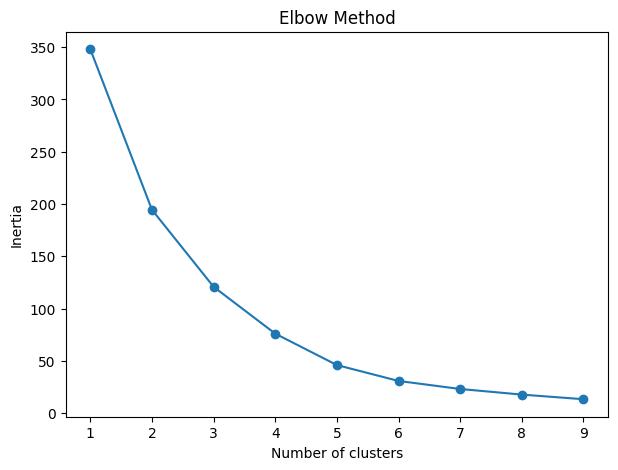

In [102]:
# Elbow Method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,10), inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [103]:
# entrenar modelo final
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df_main["cluster"] = kmeans.fit_predict(X_scaled)

df_main[["municipio","cluster"]].head()

,municipio,cluster
0,ABENGIBRE,1
1,ALATOZ,1
2,ALBACETE,2
3,ALBATANA,1
4,ALBOREA,1


In [104]:
# ver 
df_main["cluster"].value_counts()

cluster
1    48
0    37
2     1
3     1
Name: count, dtype: int64

In [105]:
# entender
df_main.groupby("cluster")[[
    "poblacion_2025",
    "renta_media_proxy",
    "gyms_google_new",
    "fitness_x10k_new"
]].mean().round(2)

,poblacion_2025,renta_media_proxy,gyms_google_new,fitness_x10k_new
cluster,,,,
0,4842.76,25407.66,4.05,9.61
1,743.96,15691.58,0.69,7.78
2,175400.00,27033.26,78.00,4.45
3,114.00,12737.11,1.00,87.72


### mi proyecto:
Data Engineering

- API Google Places
- Merge datasets
- Feature engineering

EDA
- distribución renta
- ranking municipios

ML no supervisado
- KMeans

ML supervisado
- Random Forest
- R²
- MAE
- Cross validation
- Feature importance

Business metric
- Market Gap

### proyecto de ciencia de datos completo.

### Objetivo: construir el dataset final y calcular el ranking de oportunidades fitness.

Contenido principal:

carga de datasets (población, renta, gimnasios)

limpieza de datos

feature engineering

cálculo de densidad fitness

cálculo de opportunity_score

generación del ranking de municipios

Resultado:

dataset final gym_market_opportunity_albacete.csv